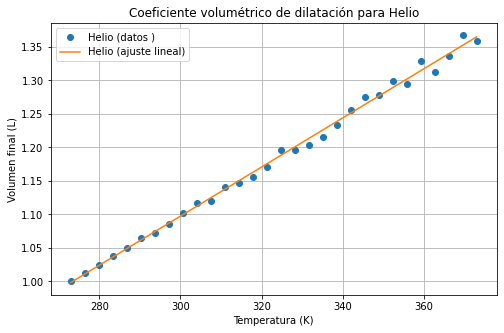


Resultados para Helio:
  Coeficiente volumétrico teórico: 0.00366 1/K
  Coeficiente volumétrico promedio : 0.00363 1/K
  Incertidumbre (95%): ±0.00004 1/K
  Ajuste lineal (volumen final vs temperatura):
    Pendiente: 0.003668 L/K
    Intercepto: -0.002848 L
    R-cuadrado: 0.9960

Tabla de datos  para Helio:
   Temperatura (K)  Volumen final (L)  Coeficiente volumétrico  (1/K)
0       273.000000           1.000000                        0.003629
1       276.448276           1.012392                        0.003594
2       279.896552           1.024531                        0.003557
3       283.344828           1.038485                        0.003720
4       286.793103           1.049394                        0.003581 



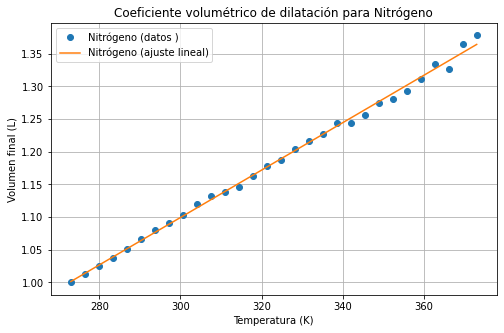


Resultados para Nitrógeno:
  Coeficiente volumétrico teórico: 0.00367 1/K
  Coeficiente volumétrico promedio : 0.00368 1/K
  Incertidumbre (95%): ±0.00004 1/K
  Ajuste lineal (volumen final vs temperatura):
    Pendiente: 0.003628 L/K
    Intercepto: 0.011101 L
    R-cuadrado: 0.9970

Tabla de datos  para Nitrógeno:
   Temperatura (K)  Volumen final (L)  Coeficiente volumétrico  (1/K)
0       273.000000           1.000000                        0.003720
1       276.448276           1.012678                        0.003677
2       279.896552           1.025857                        0.003749
3       283.344828           1.037515                        0.003626
4       286.793103           1.050672                        0.003674 



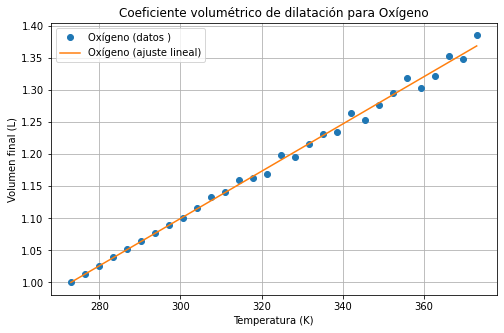


Resultados para Oxígeno:
  Coeficiente volumétrico teórico: 0.00367 1/K
  Coeficiente volumétrico promedio : 0.00370 1/K
  Incertidumbre (95%): ±0.00004 1/K
  Ajuste lineal (volumen final vs temperatura):
    Pendiente: 0.003686 L/K
    Intercepto: -0.006289 L
    R-cuadrado: 0.9959

Tabla de datos  para Oxígeno:
   Temperatura (K)  Volumen final (L)  Coeficiente volumétrico  (1/K)
0       273.000000           1.000000                        0.003674
1       276.448276           1.012677                        0.003676
2       279.896552           1.025924                        0.003759
3       283.344828           1.039277                        0.003797
4       286.793103           1.051372                        0.003725 



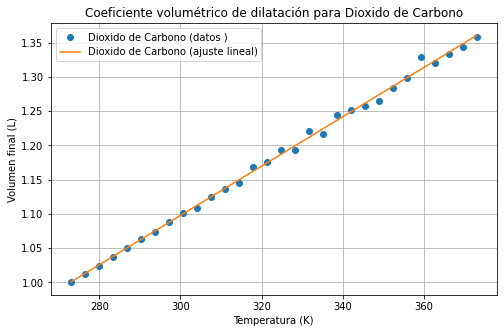


Resultados para Dioxido de Carbono:
  Coeficiente volumétrico teórico: 0.00365 1/K
  Coeficiente volumétrico promedio : 0.00361 1/K
  Incertidumbre (95%): ±0.00003 1/K
  Ajuste lineal (volumen final vs temperatura):
    Pendiente: 0.003598 L/K
    Intercepto: 0.018422 L
    R-cuadrado: 0.9976

Tabla de datos  para Dioxido de Carbono:
   Temperatura (K)  Volumen final (L)  Coeficiente volumétrico  (1/K)
0       273.000000           1.000000                        0.003743
1       276.448276           1.012093                        0.003507
2       279.896552           1.024410                        0.003539
3       283.344828           1.037671                        0.003642
4       286.793103           1.049859                        0.003615 



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress

# Constantes teóricas para los coeficientes volumétricos de dilatación (β, 1/K)
constantes = {
    "Helio": 0.00366,  # Coeficiente volumétrico teórico para el helio
    "Nitrógeno": 0.00367,  # Coeficiente volumétrico teórico para el nitrógeno
    "Oxígeno": 0.00367,  # Coeficiente volumétrico teórico para el oxígeno
    "Dioxido de Carbono": 0.00365  # Coeficiente volumétrico teórico para el CO2
}

# Función para  mediciones con incertidumbre
def simular_mediciones(beta_teorico, num_mediciones, incertidumbre_relativa):
    mediciones = beta_teorico * (1 + np.random.uniform(-incertidumbre_relativa, incertidumbre_relativa, num_mediciones))
    return mediciones

# Generar datos 
num_mediciones = 30
incertidumbre_relativa = 0.05  # 5% de incertidumbre relativa

data = {}
for gas, beta in constantes.items():
    data[gas] = simular_mediciones(beta, num_mediciones, incertidumbre_relativa)

# Análisis de datos y presentación en tabla
tablas = {}
for gas, mediciones in data.items():
    promedio = np.mean(mediciones)
    desviacion_estandar = np.std(mediciones)
    incertidumbre = desviacion_estandar / np.sqrt(num_mediciones)

    # Simulamos un experimento de dilatación volumétrica
    temperaturas = np.linspace(273, 373, num_mediciones)  # Temperaturas de 273 K a 373 K
    vol_inicial = 1.0  # Volumen inicial de 1 L
    vol_final = vol_inicial * (1 + mediciones * (temperaturas - 273))

    # Ajuste lineal: Volumen final vs Temperatura
    slope, intercept, r_value, p_value, std_err = linregress(temperaturas, vol_final)

    # Crear tabla con los datos 
    tabla = pd.DataFrame({
        "Temperatura (K)": temperaturas,
        "Volumen final (L)": vol_final,
        "Coeficiente volumétrico  (1/K)": mediciones
    })
    tablas[gas] = tabla

    # Graficar ajuste lineal
    plt.figure(figsize=(8, 5))
    plt.plot(temperaturas, vol_final, 'o', label=f"{gas} (datos )")
    plt.plot(temperaturas, slope * temperaturas + intercept, '-', label=f"{gas} (ajuste lineal)")
    plt.xlabel("Temperatura (K)")
    plt.ylabel("Volumen final (L)")
    plt.title(f"Coeficiente volumétrico de dilatación para {gas}")
    plt.legend()
    plt.grid()
    plt.show()

    # Imprimir resultados
    print(f"\nResultados para {gas}:")
    print(f"  Coeficiente volumétrico teórico: {constantes[gas]} 1/K")
    print(f"  Coeficiente volumétrico promedio : {promedio:.5f} 1/K")
    print(f"  Incertidumbre (95%): ±{2 * incertidumbre:.5f} 1/K")
    print(f"  Ajuste lineal (volumen final vs temperatura):")
    print(f"    Pendiente: {slope:.6f} L/K")
    print(f"    Intercepto: {intercept:.6f} L")
    print(f"    R-cuadrado: {r_value**2:.4f}")
    print(f"\nTabla de datos  para {gas}:")
    print(tabla.head(), "\n")
